# XWorld — Notebook 12: Observer Independence

## The question

The 5 time-domain features (skewness, kurtosis, lag1_autocorr, zero_crossings, slope) produced 7 shape classes. But those features are a choice — a particular way of holding a ruler to the data.

**Are the shape classes a property of the data, or a property of the ruler?**

Test: compute a completely different feature set — 5 spectral (frequency-domain) features derived from the FFT power spectrum. Cluster independently. Compare the resulting groupings to the time-domain taxonomy.

If the same cross-domain pairings emerge from a completely different measurement frame → observer-independence holds. The classes are real.

If different groupings emerge → some classes are artefacts of the time-domain frame.

---

## Spectral feature set

All series are interpolated to 100 points before FFT — consistent frequency resolution across series of different lengths.

| Feature | What it captures |
|---|---|
| `dominant_freq` | Normalized frequency of the peak in the power spectrum (0=DC, 0.5=Nyquist). Captures the dominant oscillation period. |
| `spectral_entropy` | Shannon entropy of the normalized power spectrum. Low = power concentrated at a few frequencies. High = broadband. |
| `power_low` | Fraction of total power in the lowest 20% of frequencies. High = slow dynamics. |
| `power_mid` | Fraction in frequencies 20–60%. |
| `power_high` | Fraction in the top 40% of frequencies. High = fast oscillations. |

These 5 features share no mathematical overlap with the 5 time-domain features.

---

## Pre-run predictions

| Dataset | Expected spectral character | Spectral cluster prediction |
|---|---|---|
| covid_first_wave | Near-DC dominant freq, low entropy, very high power_low | Own cluster — slow one-time event |
| covid_second_wave | Same as first wave | Same cluster as covid_first_wave |
| keeling_trend | Even more DC-concentrated than COVID | Possibly with COVID or own cluster |
| keeling_seasonal | Sharp peak at 1/12 normalized freq, very low entropy | Own cluster — cleanest spectral signature |
| sunspot_cycle | Peak at ~1/132 months, low entropy | **Should separate from COVID here** — periodic peak vs no peak |
| lynx_hare | Peak ~1/10 yr, moderate entropy | Own cluster or with sunspot |
| temperature | Broadband, high entropy, moderate power_low | Own cluster |
| ecg | Peak at ~heartbeat freq (~1/0.8s), low entropy | Own cluster — fastest periodic signal |
| streamflow | Peak at 1/12 months (annual cycle), low entropy | May group with keeling_seasonal |

## Key observer-independence tests

1. **COVID1 + COVID2 still together?** Both are slow one-time bursts — same dominant freq, same spectral entropy.
2. **keeling_seasonal isolated?** Sharpest spectral peak of any dataset — annual CO2 cycle is the most regular signal.
3. **Sunspot separates from COVID?** In time-domain they collapsed together. In spectral space sunspot has a clear periodic peak (~11yr); COVID has no periodic peak — just DC energy. This is the key test.
4. **ECG isolated?** Fastest oscillatory signal — unique frequency band.
5. **keeling_trend vs COVID** — both near-DC, but trend is purely DC while burst has more broadband energy from the rise and fall.

In [1]:
import requests
import urllib.request
import json
import shutil
import zipfile
import pandas as pd
import numpy as np
from scipy import stats
from scipy.signal import find_peaks
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score
import hdbscan
import umap
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

RAW_DIR = Path('../data/raw')
PROCESSED_DIR = Path('../data/processed')
RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

SPECTRAL_COLS = ['dominant_freq', 'spectral_entropy', 'power_low', 'power_mid', 'power_high']
TIMEDOM_COLS  = ['skewness', 'kurtosis', 'lag1_autocorr', 'zero_crossings', 'slope']
INTERP_LEN = 100  # all series interpolated to this length before FFT

print('Imports OK')
print(f'Spectral features: {SPECTRAL_COLS}')
print(f'Time-domain features (reference): {TIMEDOM_COLS}')

/home/skrsan/Documents/Projects/xworld/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports OK
Spectral features: ['dominant_freq', 'spectral_entropy', 'power_low', 'power_mid', 'power_high']
Time-domain features (reference): ['skewness', 'kurtosis', 'lag1_autocorr', 'zero_crossings', 'slope']


In [2]:
# ============================================================
# SHARED HELPERS
# ============================================================

def zscore_normalize(s):
    s = np.asarray(s, dtype=float)
    std = s.std()
    return (s - s.mean()) / std if std > 0 else s - s.mean()


def interp_to_length(s, n=INTERP_LEN):
    """Interpolate series to fixed length for comparable FFT."""
    x_orig = np.linspace(0, 1, len(s))
    x_new  = np.linspace(0, 1, n)
    return np.interp(x_new, x_orig, s)


def spectral_features(series):
    """5 frequency-domain features from a z-score normalized series.
    Series is first interpolated to INTERP_LEN points.
    """
    s = interp_to_length(zscore_normalize(np.asarray(series, dtype=float)))
    n = len(s)

    # One-sided power spectrum (positive frequencies only)
    fft_vals = np.fft.rfft(s)
    power    = np.abs(fft_vals) ** 2
    freqs    = np.fft.rfftfreq(n)  # 0 to 0.5, length = n//2 + 1

    # Exclude DC (index 0) for entropy/band calculations to avoid DC domination
    power_ac = power[1:]   # AC power only
    freqs_ac = freqs[1:]
    total_ac = power_ac.sum() if power_ac.sum() > 0 else 1.0

    # Dominant frequency: index of max power (including DC)
    dom_idx  = np.argmax(power)
    dom_freq = float(freqs[dom_idx])

    # Spectral entropy: Shannon entropy of normalized AC power
    p_norm = power_ac / total_ac
    p_norm = p_norm[p_norm > 0]  # avoid log(0)
    sp_entropy = float(-np.sum(p_norm * np.log(p_norm)))
    # Normalize by max possible entropy (uniform spectrum)
    sp_entropy /= np.log(len(power_ac)) if len(power_ac) > 1 else 1.0

    # Power bands (AC power only, normalized)
    n_ac = len(freqs_ac)
    low_end  = int(n_ac * 0.20)
    mid_end  = int(n_ac * 0.60)
    p_low  = float(power_ac[:low_end].sum()  / total_ac)
    p_mid  = float(power_ac[low_end:mid_end].sum() / total_ac)
    p_high = float(power_ac[mid_end:].sum()  / total_ac)

    return {
        'dominant_freq':    dom_freq,
        'spectral_entropy':  sp_entropy,
        'power_low':        p_low,
        'power_mid':        p_mid,
        'power_high':       p_high,
    }


print('Spectral feature helpers defined')

# Quick sanity check on a sine wave
test_sine = np.sin(2 * np.pi * np.linspace(0, 4, 100))  # 4 full cycles in 100 points
f = spectral_features(test_sine)
print(f'Sine wave (4 cycles/100pts) — dominant_freq={f["dominant_freq"]:.3f}  entropy={f["spectral_entropy"]:.3f}  power_low={f["power_low"]:.3f}')
# Expected: dominant_freq ≈ 0.04 (4/100), low spectral entropy (concentrated), low power_low (energy in mid band)

Spectral feature helpers defined
Sine wave (4 cycles/100pts) — dominant_freq=0.040  entropy=0.012  power_low=0.999


---
## Series Re-extraction

All raw data is cached in `data/raw/` from notebook 11. Each dataset section re-extracts the normalized series and computes spectral features.

In [3]:
# COVID first + second wave — reuse cached OWID file
dest = RAW_DIR / 'owid_covid.csv'
if not dest.exists():
    print('Downloading OWID COVID...')
    r = requests.get('https://github.com/owid/covid-19-data/raw/master/public/data/owid-covid-data.csv', stream=True)
    with open(dest, 'wb') as f:
        for chunk in r.iter_content(8192): f.write(chunk)
df_raw = pd.read_csv(dest, usecols=['location','date','new_cases_smoothed_per_million','continent'], parse_dates=['date'])
df_covid = df_raw.dropna(subset=['continent']).rename(columns={'new_cases_smoothed_per_million':'cases_pm'})
print(f'COVID data loaded: {df_covid.location.nunique()} countries')

def extract_first_wave(series, max_days=180, min_days=30):
    s = series.fillna(0).values
    starts = np.where(s > 0.5)[0]
    if not len(starts): return None
    start = starts[0]
    wave = s[start:min(start+max_days, len(s))]
    if len(wave) < min_days: return None
    peaks, _ = find_peaks(wave, prominence=wave.max()*0.2)
    if not len(peaks): return None
    wave = wave[:min(peaks[0]+60, len(wave))]
    return wave if len(wave) >= min_days else None

def extract_second_wave(series, min_days=30):
    s = series.fillna(0).values
    peaks, _ = find_peaks(s, prominence=s.max()*0.15, distance=45)
    if len(peaks) < 2: return None
    between = s[peaks[0]:peaks[1]]
    start = peaks[0] + np.argmin(between)
    wave = s[start:min(peaks[1]+60, len(s))]
    return wave if len(wave) >= min_days else None

records = []
for country, grp in df_covid.groupby('location'):
    grp = grp.sort_values('date')
    for wave_fn, ds_name in [(extract_first_wave, 'covid_first_wave'), (extract_second_wave, 'covid_second_wave')]:
        w = wave_fn(grp['cases_pm'])
        if w is not None:
            arr = zscore_normalize(w)
            feats = spectral_features(arr)
            feats['country'] = country
            feats['dataset'] = ds_name
            feats['n_points'] = len(arr)
            records.append(feats)

df_covid_spec = pd.DataFrame(records)
print(f'COVID spectral features: {df_covid_spec.dataset.value_counts().to_dict()}')
print(f'Mean dominant_freq — first wave: {df_covid_spec[df_covid_spec.dataset=="covid_first_wave"]["dominant_freq"].mean():.4f}')
print(f'Mean dominant_freq — second wave: {df_covid_spec[df_covid_spec.dataset=="covid_second_wave"]["dominant_freq"].mean():.4f}')

COVID data loaded: 243 countries
COVID spectral features: {'covid_second_wave': 209, 'covid_first_wave': 202}
Mean dominant_freq — first wave: 0.0113
Mean dominant_freq — second wave: 0.0111


In [4]:
dest = RAW_DIR / 'sunspot_monthly.csv'
if not dest.exists():
    dest.write_bytes(requests.get('https://www.sidc.be/silso/DATA/SN_m_tot_V2.0.csv').content)
df_ss = pd.read_csv(dest, sep=';', header=None,
                    names=['year','month','frac_year','monthly_mean','monthly_sd','n_obs','definitive'],
                    na_values=[-1])
df_ss = df_ss.dropna(subset=['monthly_mean'])
df_ss['smooth'] = df_ss['monthly_mean'].rolling(13, center=True).mean()
series_full = df_ss['smooth'].bfill().ffill().values
smoothed = pd.Series(series_full).rolling(25, center=True).mean().bfill().ffill().values
minima, _ = find_peaks(-smoothed, distance=80)

cycles = {}
for i in range(len(minima)-1):
    s, e = minima[i], minima[i+1]
    c = series_full[s:e]
    if len(c) >= 80:
        cycles[f'cycle_{i+1}_{int(df_ss["year"].iloc[s])}'] = c
print(f'Sunspot cycles: {len(cycles)}')

records = []
for name, cycle in cycles.items():
    feats = spectral_features(cycle)
    feats['country'] = name
    feats['dataset'] = 'sunspot_cycle'
    feats['n_points'] = len(cycle)
    records.append(feats)
df_ss_spec = pd.DataFrame(records)
print(f'Mean dominant_freq: {df_ss_spec["dominant_freq"].mean():.4f}  (expected > 0 — periodic)')
print(f'Mean spectral_entropy: {df_ss_spec["spectral_entropy"].mean():.4f}  (expected low — concentrated)')

Sunspot cycles: 24
Mean dominant_freq: 0.0100  (expected > 0 — periodic)
Mean spectral_entropy: 0.0805  (expected low — concentrated)


In [5]:
lynx_path = Path('../datasets/lynx_hare/lynx_hare.csv')
df_lh = pd.read_csv(lynx_path)
year_col = [c for c in df_lh.columns if c.lower() == 'year'][0]
species_cols = [c for c in df_lh.columns if c.lower() != 'year']

window_size = 10
series_dict = {}
for sp in species_cols:
    full = df_lh[sp].values.astype(float)
    series_dict[f'{sp}_full'] = full
    for start in range(len(full) - window_size + 1):
        series_dict[f'{sp}_w{start}_{df_lh[year_col].iloc[start]}'] = full[start:start+window_size]
print(f'Lynx-hare series: {len(series_dict)}')

records = []
for name, s in series_dict.items():
    feats = spectral_features(s)
    feats['country'] = name
    feats['dataset'] = 'lynx_hare'
    feats['n_points'] = len(s)
    records.append(feats)
df_lh_spec = pd.DataFrame(records)
print(f'Mean dominant_freq: {df_lh_spec["dominant_freq"].mean():.4f}')

Lynx-hare series: 26
Mean dominant_freq: 0.0108


In [6]:
dest = RAW_DIR / 'keeling_monthly.csv'
if not dest.exists():
    dest.write_bytes(requests.get('https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.csv').content)
co2 = pd.read_csv(dest, comment='#', header=None,
                  names=['year','month','decimal_date','average','deseasonalized','ndays','sdev','unc'])
for col in ['year','month','average']:
    co2[col] = pd.to_numeric(co2[col], errors='coerce')
co2 = co2.dropna(subset=['year','month','average'])
co2 = co2[co2['average'] > 0].copy()
co2.index = pd.to_datetime({'year': co2['year'].astype(int), 'month': co2['month'].astype(int), 'day': 1})

result = seasonal_decompose(co2['average'], model='additive', period=12, extrapolate_trend='freq')
seasonal_vals = result.seasonal.dropna().values
trend_vals    = result.trend.dropna().values
start_year    = co2.index.min().year

series_dict = {}
for i in range(len(seasonal_vals) // 12):
    seg = seasonal_vals[i*12:(i+1)*12]
    if len(seg) == 12:
        series_dict[f'keeling_seasonal_{start_year+i}'] = seg
for i in range(0, len(trend_vals) - 120, 12):
    series_dict[f'keeling_trend_{start_year + i//12}'] = trend_vals[i:i+120]
print(f'Keeling series: {sum(1 for k in series_dict if "seasonal" in k)} seasonal, {sum(1 for k in series_dict if "trend" in k)} trend')

records = []
for name, s in series_dict.items():
    feats = spectral_features(s)
    feats['country'] = name
    feats['dataset'] = 'keeling_seasonal' if 'seasonal' in name else 'keeling_trend'
    feats['n_points'] = len(s)
    records.append(feats)
df_k_spec = pd.DataFrame(records)
for ds in ['keeling_seasonal', 'keeling_trend']:
    sub = df_k_spec[df_k_spec['dataset'] == ds]
    print(f'{ds}: dom_freq={sub["dominant_freq"].mean():.4f}  entropy={sub["spectral_entropy"].mean():.4f}  power_low={sub["power_low"].mean():.3f}')

Keeling series: 68 seasonal, 58 trend
keeling_seasonal: dom_freq=0.0100  entropy=0.0454  power_low=0.999
keeling_trend: dom_freq=0.0100  entropy=0.4042  power_low=0.944


In [7]:
dest = RAW_DIR / 'temperature_anomaly.csv'
if not dest.exists():
    print('Downloading Berkeley Earth temperature...')
    try:
        r = requests.get('https://berkeley-earth-temperature.s3.amazonaws.com/Global/Land_and_Ocean_summary.txt',
                         headers={'User-Agent': 'Mozilla/5.0'}, timeout=30)
        r.raise_for_status()
        dest.write_bytes(r.content)
    except Exception as e:
        raise RuntimeError(f'Temperature download failed: {e}. Place file at {dest}')
with open(dest) as f:
    raw = f.read()
is_berkeley = raw.lstrip().startswith('%')
if is_berkeley:
    lines = [l for l in raw.splitlines() if l.strip() and not l.strip().startswith('%')]
    rows = []
    for line in lines:
        parts = line.split()
        if len(parts) >= 2:
            try: rows.append({'year': int(float(parts[0])), 'anomaly': float(parts[1])})
            except ValueError: continue
    df_temp = pd.DataFrame(rows).dropna()
else:
    lines = raw.splitlines()
    header_idx = next(i for i, l in enumerate(lines) if 'Year' in l and 'J-D' in l)
    df_temp = pd.read_csv(dest, skiprows=header_idx, na_values=['***','****'])
    df_temp = df_temp[['Year','J-D']].rename(columns={'Year':'year','J-D':'anomaly'})
    df_temp['year'] = pd.to_numeric(df_temp['year'], errors='coerce')
    df_temp['anomaly'] = pd.to_numeric(df_temp['anomaly'], errors='coerce')
    df_temp = df_temp.dropna()
    df_temp['year'] = df_temp['year'].astype(int)
values = df_temp['anomaly'].values
years  = df_temp['year'].values
window, step = 20, 5
series_dict = {}
for i in range(0, len(values) - window, step):
    series_dict[f'temp_{years[i]}'] = values[i:i+window]
print(f'Temperature windows: {len(series_dict)}')

records = []
for name, s in series_dict.items():
    feats = spectral_features(s)
    feats['country'] = name
    feats['dataset'] = 'temperature'
    feats['n_points'] = len(s)
    records.append(feats)
df_temp_spec = pd.DataFrame(records)
print(f'Mean entropy: {df_temp_spec["spectral_entropy"].mean():.4f}  (expected high — broadband noise)')

Temperature windows: 31
Mean entropy: 0.4314  (expected high — broadband noise)


In [8]:
dest_zip = RAW_DIR / 'ECGFiveDays.zip'
dest_dir = RAW_DIR / 'ECGFiveDays'
if dest_dir.exists() and list(dest_dir.rglob('*.ts')):
    print(f'Cached: {dest_dir}')
elif dest_zip.exists():
    print('Extracting ECG zip...')
    if dest_dir.exists(): shutil.rmtree(dest_dir)
    with zipfile.ZipFile(dest_zip) as z: z.extractall(dest_dir)
else:
    raise RuntimeError('ECGFiveDays.zip not found. Place it in data/raw/')
ts_files = list(dest_dir.rglob('*.ts'))
print(f'.ts files: {[f.name for f in ts_files]}')

def parse_ts_file(path):
    series_list, labels = [], []
    in_data = False
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line: continue
            if line.lower() == '@data': in_data = True; continue
            if in_data and not line.startswith('@'):
                if ':' in line:
                    data_part, label = line.rsplit(':', 1)
                    values = [float(x) for x in data_part.split(',') if x.strip()]
                else:
                    parts = line.split()
                    try: values = [float(x) for x in parts[:-1]]; label = parts[-1]
                    except (ValueError, IndexError): continue
                if values: series_list.append(np.array(values)); labels.append(label.strip())
    return series_list, labels

all_series, all_labels = [], []
for ts_file in ts_files:
    s, l = parse_ts_file(ts_file)
    print(f'  {ts_file.name}: {len(s)} segments')
    all_series.extend(s); all_labels.extend(l)
print(f'ECG total: {len(all_series)}')

records = []
for i, (s, label) in enumerate(zip(all_series, all_labels)):
    feats = spectral_features(s)
    feats['country'] = f'ecg_{i}_c{label}'
    feats['dataset'] = 'ecg'
    feats['n_points'] = len(s)
    records.append(feats)
df_ecg_spec = pd.DataFrame(records)
print(f'Mean dominant_freq: {df_ecg_spec["dominant_freq"].mean():.4f}  (expected high — fast heartbeat)')

Cached: ../data/raw/ECGFiveDays
.ts files: ['ECGFiveDays_TRAIN.ts', 'ECGFiveDays_TEST.ts']
  ECGFiveDays_TRAIN.ts: 23 segments
  ECGFiveDays_TEST.ts: 861 segments
ECG total: 884
Mean dominant_freq: 0.0236  (expected high — fast heartbeat)


In [9]:
STATIONS = {
    '01350000':'mohawk_ny',    '01427207':'delaware_ny', '01491000':'choptank_md',
    '02087500':'neuse_nc',     '02339500':'flint_ga',    '03049000':'allegheny_pa',
    '03611500':'ohio_il',      '05054000':'red_nd',      '05378500':'mississippi_mn',
    '05420500':'mississippi_ia','06289000':'bighorn_mt', '06600000':'missouri_ia',
    '07022000':'mississippi_mo','07289000':'mississippi_ms','08220000':'riogrande_co',
    '09180000':'colorado_ut',  '09380000':'colorado_az', '11530000':'klamath_ca',
    '02427250':'alabama_al',    '12374250':'clearwater_id','14105700':'columbia_or',
    '14179000':'willamette_or','06354000':'cannonball_nd','02479155':'escatawpa_ms',
    '01096500':'nashua_ma',
}

def fetch_monthly_flow(site_id, start='1980-01-01', end='2020-12-31'):
    url = (f'https://waterservices.usgs.gov/nwis/dv/?format=json'
           f'&sites={site_id}&parameterCd=00060&statCd=00003&startDT={start}&endDT={end}')
    try:
        req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
        with urllib.request.urlopen(req, timeout=45) as resp:
            data = json.loads(resp.read())
        series = data['value']['timeSeries']
        if not series: return None
        values = series[0]['values'][0]['value']
        records = []
        for v in values:
            try: records.append({'date': pd.Timestamp(v['dateTime'][:10]), 'flow': float(v['value'])})
            except (ValueError, KeyError): continue
        if len(records) < 365: return None
        df = pd.DataFrame(records).set_index('date')
        monthly = df['flow'].resample('MS').mean().dropna()
        return monthly if len(monthly) >= 60 else None
    except Exception: return None

print(f'Fetching {len(STATIONS)} USGS stations...')
flows = {}
for site_id, name in STATIONS.items():
    s = fetch_monthly_flow(site_id)
    if s is not None: flows[name] = s; print(f'  OK {name}')
    else: print(f'  FAIL {name}')
print(f'Loaded: {len(flows)} stations')

records = []
for name, series in flows.items():
    log_flow = np.log1p(series.values.astype(float))
    feats = spectral_features(log_flow)
    feats['country'] = name
    feats['dataset'] = 'streamflow'
    feats['n_points'] = len(log_flow)
    records.append(feats)
df_sf_spec = pd.DataFrame(records)
print(f'Mean dominant_freq: {df_sf_spec["dominant_freq"].mean():.4f}  (expected ~0.08 — annual cycle in monthly data)')

Fetching 25 USGS stations...
  OK mohawk_ny
  OK delaware_ny
  OK choptank_md
  OK neuse_nc
  OK flint_ga
  OK allegheny_pa
  OK ohio_il
  OK red_nd
  OK mississippi_mn
  OK mississippi_ia
  OK bighorn_mt
  OK missouri_ia
  OK mississippi_mo
  OK mississippi_ms
  OK riogrande_co
  OK colorado_ut
  OK colorado_az
  OK klamath_ca
  FAIL queets_wa
  OK clearwater_id
  OK columbia_or
  OK willamette_or
  OK cannonball_nd
  OK escatawpa_ms
  OK nashua_ma
Loaded: 24 stations
Mean dominant_freq: 0.3533  (expected ~0.08 — annual cycle in monthly data)


---
## Combine all spectral features

In [10]:
dfs_spec = [df_covid_spec, df_ss_spec, df_lh_spec, df_k_spec, df_temp_spec, df_ecg_spec, df_sf_spec]
df_spec = pd.concat(dfs_spec, ignore_index=True)
df_spec.to_csv(PROCESSED_DIR / 'features_spectral.csv', index=False)
print(f'Total: {len(df_spec)} instances, {df_spec.dataset.nunique()} datasets')
print(df_spec['dataset'].value_counts())
print()
print('=== Spectral feature summary per dataset ===')
print(df_spec.groupby('dataset')[SPECTRAL_COLS].mean().round(4).to_string())

Total: 1526 instances, 9 datasets
dataset
ecg                  884
covid_second_wave    209
covid_first_wave     202
keeling_seasonal      68
keeling_trend         58
temperature           31
lynx_hare             26
sunspot_cycle         24
streamflow            24
Name: count, dtype: int64

=== Spectral feature summary per dataset ===
                   dominant_freq  spectral_entropy  power_low  power_mid  power_high
dataset                                                                             
covid_first_wave          0.0113            0.3297     0.9577     0.0346      0.0076
covid_second_wave         0.0111            0.3121     0.9501     0.0375      0.0123
ecg                       0.0236            0.7361     0.6829     0.3050      0.0121
keeling_seasonal          0.0100            0.0454     0.9995     0.0004      0.0001
keeling_trend             0.0100            0.4042     0.9439     0.0423      0.0137
lynx_hare                 0.0108            0.1797     0.9932     

---
## Visualise spectral profiles

Before clustering — sanity check that the spectral features are discriminating.

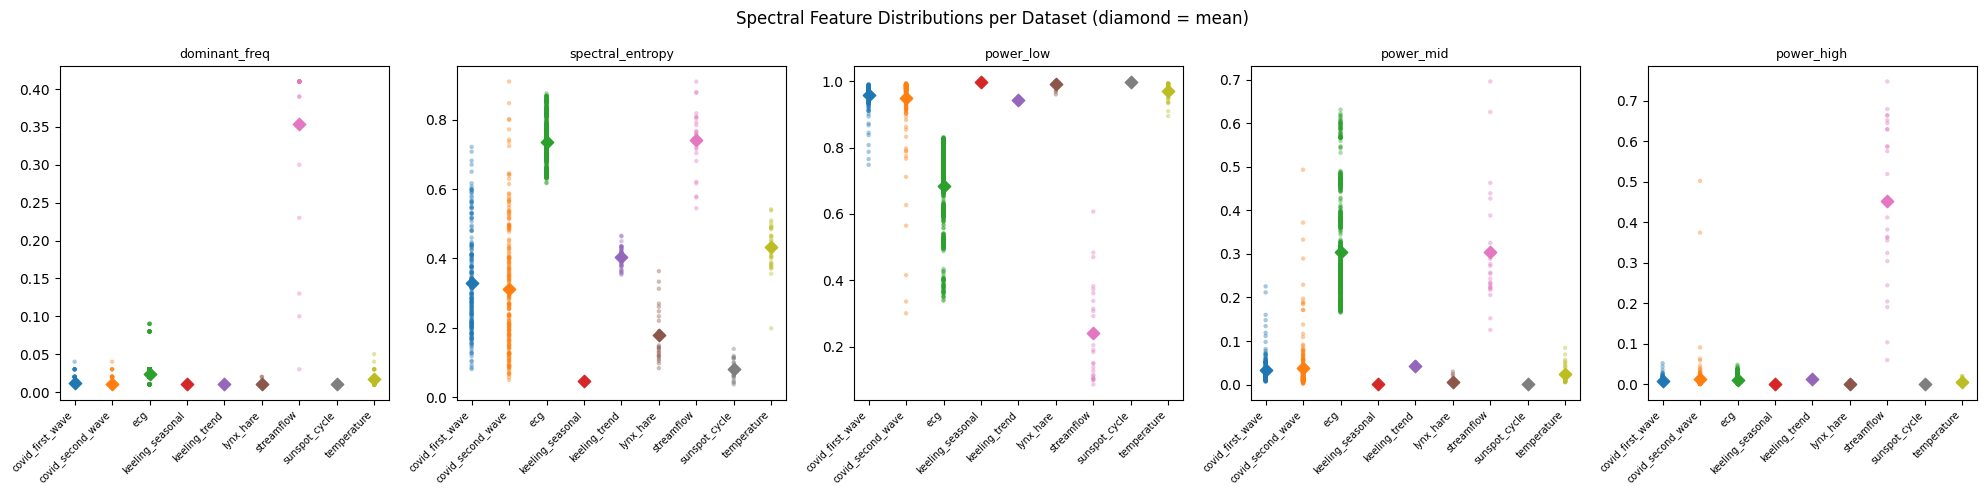

In [11]:
datasets_list = sorted(df_spec['dataset'].unique())
palette = dict(zip(datasets_list, sns.color_palette('tab10', len(datasets_list))))

fig, axes = plt.subplots(1, len(SPECTRAL_COLS), figsize=(20, 5))
for ax, feat in zip(axes, SPECTRAL_COLS):
    for ds in datasets_list:
        vals = df_spec[df_spec['dataset'] == ds][feat]
        ax.scatter([ds] * len(vals), vals, alpha=0.4, s=10, color=palette[ds], edgecolors='none')
        ax.scatter([ds], [vals.mean()], marker='D', s=40, color=palette[ds], zorder=5)
    ax.set_title(feat, fontsize=9)
    ax.set_xticklabels(datasets_list, rotation=45, ha='right', fontsize=7)
plt.suptitle('Spectral Feature Distributions per Dataset (diamond = mean)', fontsize=12)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'spectral_features_by_dataset.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Spectral Clustering (independent of time-domain features)

In [12]:
df_clean = df_spec.dropna(subset=SPECTRAL_COLS).copy()
domain_int = pd.factorize(df_clean['dataset'])[0]

X = df_clean[SPECTRAL_COLS].values
X_scaled = StandardScaler().fit_transform(X)

reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
embedding = reducer.fit_transform(X_scaled)

clusterer = hdbscan.HDBSCAN(min_cluster_size=8, min_samples=3, metric='euclidean')
spec_labels = clusterer.fit_predict(X_scaled)

df_clean['cluster_spec'] = spec_labels
df_clean['umap_x'] = embedding[:, 0]
df_clean['umap_y'] = embedding[:, 1]

n_clusters = len(set(spec_labels)) - (1 if -1 in spec_labels else 0)
noise      = (spec_labels == -1).sum()
non_noise  = spec_labels != -1
ari        = adjusted_rand_score(domain_int[non_noise], spec_labels[non_noise])

print(f'Spectral clustering: clusters={n_clusters}  noise={noise} ({100*noise/len(spec_labels):.1f}%)  ARI={ari:.3f}')

Spectral clustering: clusters=37  noise=328 (21.5%)  ARI=0.132


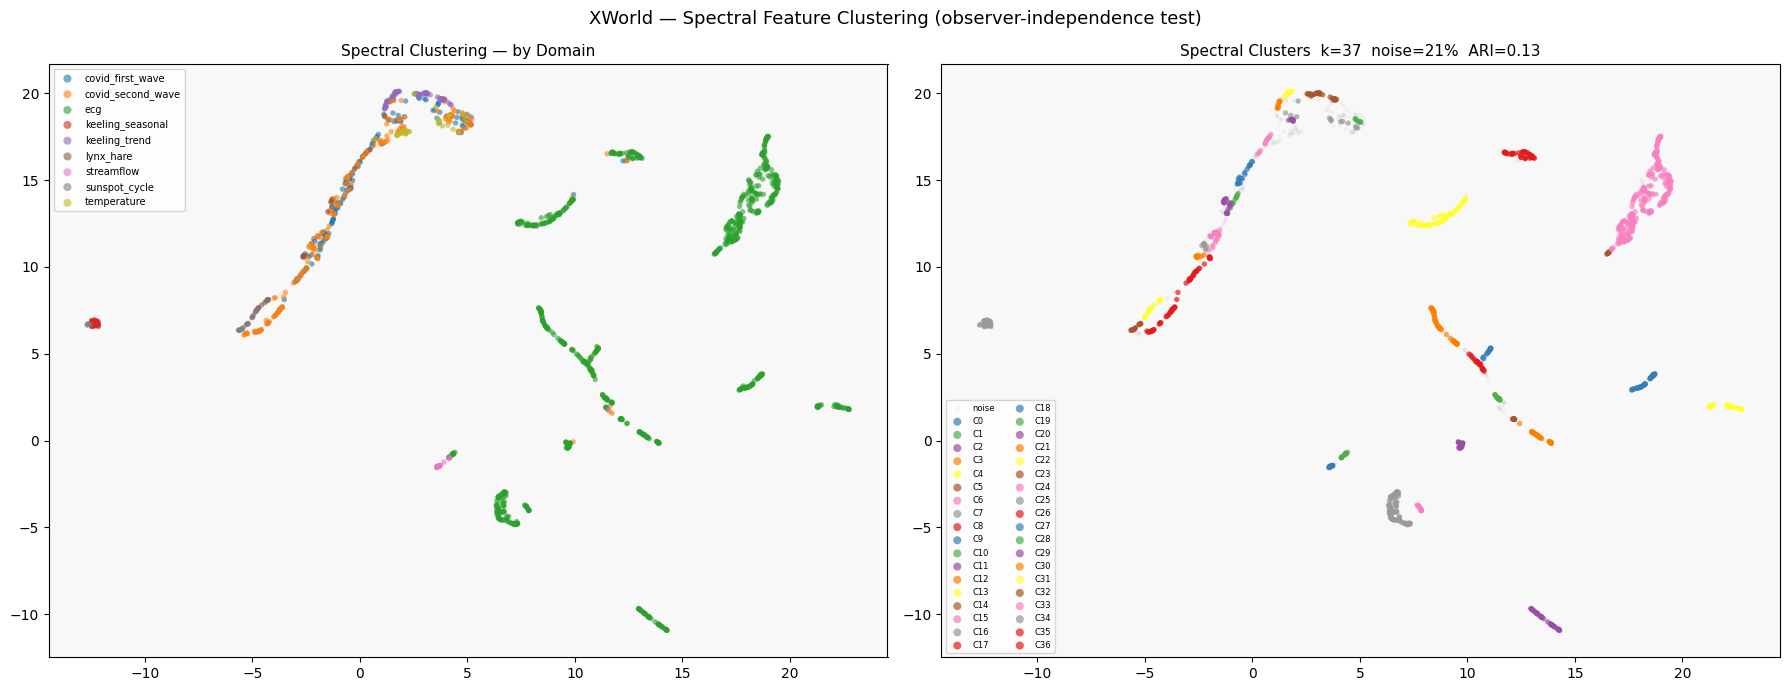

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: by domain
for ds in datasets_list:
    mask = df_clean['dataset'] == ds
    axes[0].scatter(df_clean.loc[mask,'umap_x'], df_clean.loc[mask,'umap_y'],
                    c=[palette[ds]], label=ds, alpha=0.6, s=15, edgecolors='none')
axes[0].set_title('Spectral Clustering — by Domain', fontsize=11)
axes[0].legend(fontsize=7, markerscale=1.5)
axes[0].set_facecolor('#f8f8f8')

# Right: by cluster
unique_cl = sorted(set(spec_labels))
n_real = len([c for c in unique_cl if c != -1])
cl_pal = {c: 'lightgrey' if c==-1 else sns.color_palette('Set1', max(n_real,1))[i % max(n_real,1)]
          for i, c in enumerate(unique_cl)}
for c in unique_cl:
    mask = df_clean['cluster_spec'] == c
    axes[1].scatter(df_clean.loc[mask,'umap_x'], df_clean.loc[mask,'umap_y'],
                    c=[cl_pal[c]], label='noise' if c==-1 else f'C{c}',
                    alpha=0.7 if c!=-1 else 0.2, s=15 if c!=-1 else 8, edgecolors='none')
axes[1].set_title(f'Spectral Clusters  k={n_clusters}  noise={100*noise/len(spec_labels):.0f}%  ARI={ari:.2f}', fontsize=11)
axes[1].legend(fontsize=6, markerscale=1.5, ncol=2)
axes[1].set_facecolor('#f8f8f8')

plt.suptitle('XWorld — Spectral Feature Clustering (observer-independence test)', fontsize=13)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'spectral_clustering_umap.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
print('=== Spectral cluster taxonomy ===')
crosstab = pd.crosstab(df_clean['cluster_spec'], df_clean['dataset'])
real = crosstab[(crosstab.index != -1) & (crosstab.sum(axis=1) >= 5)]
print(real.to_string())
print()
profiles = df_clean[df_clean['cluster_spec'] != -1].groupby('cluster_spec')[SPECTRAL_COLS].mean().round(4)
print('Mean spectral profile per cluster:')
print(profiles.to_string())

=== Spectral cluster taxonomy ===
dataset       covid_first_wave  covid_second_wave  ecg  keeling_seasonal  keeling_trend  lynx_hare  streamflow  sunspot_cycle  temperature
cluster_spec                                                                                                                              
0                            0                  0    0                 0              0          0          19              0            0
1                            0                  0   18                 0              0          0           0              0            0
2                            0                  0   30                 0              0          0           0              0            0
3                            0                  0   39                 0              0          0           0              0            0
4                            0                  0   46                 0              0          0           0              0       

---
## Observer-Independence Comparison

Load time-domain cluster assignments from notebook 11 and compare directly.

In [15]:
# Load 5-feature time-domain features from nb11 CSVs and re-run clustering
# (so we have assignments on the same set of instances)
feature_files = [
    ('features_covid_first_wave.csv',  None),
    ('features_covid_second_wave.csv', None),
    ('features_sunspot_cycles.csv',    None),
    ('features_lynx_hare.csv',         None),
    ('features_keeling.csv',           None),
    ('features_keeling_all.csv',       None),
    ('features_temperature.csv',       None),
    ('features_ecg.csv',               None),
    ('features_streamflow.csv',        None),
]

dfs_td = []
loaded_ds = set()
for fname, _ in feature_files:
    path = PROCESSED_DIR / fname
    if not path.exists(): continue
    df = pd.read_csv(path)
    new_ds = set(df['dataset'].unique()) - loaded_ds
    if not new_ds: continue
    df = df[df['dataset'].isin(new_ds)]
    dfs_td.append(df)
    loaded_ds |= new_ds

df_td = pd.concat(dfs_td, ignore_index=True)
print(f'Time-domain features loaded: {len(df_td)} rows, {df_td.dataset.nunique()} datasets')

# Use 6-feature set (including baseline_delta) from nb11
td_cols = [c for c in ['skewness','kurtosis','lag1_autocorr','zero_crossings','slope','baseline_delta'] if c in df_td.columns]
print(f'Using time-domain columns: {td_cols}')

df_td_clean = df_td.dropna(subset=td_cols).copy()
X_td = StandardScaler().fit_transform(df_td_clean[td_cols].values)
td_labels = hdbscan.HDBSCAN(min_cluster_size=8, min_samples=3).fit_predict(X_td)
df_td_clean['cluster_td'] = td_labels

n_td = len(set(td_labels)) - (1 if -1 in td_labels else 0)
noise_td = (td_labels == -1).sum()
print(f'Time-domain clustering: clusters={n_td}  noise={noise_td} ({100*noise_td/len(td_labels):.1f}%)')

Time-domain features loaded: 1526 rows, 9 datasets
Using time-domain columns: ['skewness', 'kurtosis', 'lag1_autocorr', 'zero_crossings', 'slope', 'baseline_delta']
Time-domain clustering: clusters=21  noise=397 (26.0%)


In [16]:
# Align on country+dataset to compare assignments
# Both notebooks use the same 'country' key within each dataset
df_spec_align = df_clean[['country','dataset','cluster_spec']].copy()
df_td_align   = df_td_clean[['country','dataset','cluster_td']].copy()

df_merged = pd.merge(df_spec_align, df_td_align, on=['country','dataset'], how='inner')
print(f'Matched instances (same country+dataset in both): {len(df_merged)}')
print(f'  (spectral had {len(df_spec_align)}, time-domain had {len(df_td_align)})')
print()

# Exclude noise from both sides for ARI
both_real = (df_merged['cluster_spec'] != -1) & (df_merged['cluster_td'] != -1)
ari_cross = adjusted_rand_score(df_merged.loc[both_real,'cluster_td'], df_merged.loc[both_real,'cluster_spec'])
print(f'Cross-frame ARI (spectral vs time-domain, non-noise): {ari_cross:.3f}')
print()
print('Interpretation: ARI=1.0 means identical groupings (perfect observer-independence)')
print('               ARI=0.0 means no better than random')
print('               ARI>0.3 means meaningful structural agreement')

Matched instances (same country+dataset in both): 1526
  (spectral had 1526, time-domain had 1526)

Cross-frame ARI (spectral vs time-domain, non-noise): 0.484

Interpretation: ARI=1.0 means identical groupings (perfect observer-independence)
               ARI=0.0 means no better than random
               ARI>0.3 means meaningful structural agreement


In [17]:
print('=== Key pairing tests ===')
print()

def majority_cluster(df, ds, col):
    c = df[df['dataset'] == ds][col].value_counts()
    real = c[c.index != -1]
    return real.index[0] if len(real) > 0 else -1

# Test 1: COVID1 + COVID2 still together in spectral space?
c1_spec = majority_cluster(df_clean, 'covid_first_wave', 'cluster_spec')
c2_spec = majority_cluster(df_clean, 'covid_second_wave', 'cluster_spec')
pct1 = 100*(df_clean[df_clean['dataset']=='covid_first_wave']['cluster_spec']==c1_spec).mean()
pct2 = 100*(df_clean[df_clean['dataset']=='covid_second_wave']['cluster_spec']==c2_spec).mean()
print(f'COVID1 → Cluster {c1_spec} ({pct1:.0f}%)  |  COVID2 → Cluster {c2_spec} ({pct2:.0f}%)')
print(f'  COVID1+COVID2 together: {"YES ✓" if c1_spec==c2_spec else "NO"}')
print()

# Test 2: Sunspot vs COVID — THE KEY TEST
sun_spec = majority_cluster(df_clean, 'sunspot_cycle', 'cluster_spec')
print(f'Sunspot → Cluster {sun_spec}  |  COVID → Cluster {c1_spec}')
if sun_spec != c1_spec:
    print(f'  Sunspot SEPARATES from COVID in spectral space ✓')
    print(f'  → Time-domain collapse (Finding 10) was a frame limitation, not a genuine shape similarity')
else:
    print(f'  Sunspot still in COVID cluster — shapes may be genuinely similar across both frames')
print()

# Test 3: keeling_seasonal isolated?
ks_spec = majority_cluster(df_clean, 'keeling_seasonal', 'cluster_spec')
kt_spec = majority_cluster(df_clean, 'keeling_trend', 'cluster_spec')
pct_ks = 100*(df_clean[df_clean['dataset']=='keeling_seasonal']['cluster_spec']==ks_spec).mean()
print(f'keeling_seasonal → Cluster {ks_spec} ({pct_ks:.0f}%)')
print(f'keeling_trend    → Cluster {kt_spec}')
print(f'  keeling_seasonal isolated from keeling_trend: {"YES ✓" if ks_spec!=kt_spec else "NO"}')
print()

# Test 4: ECG isolated?
ecg_spec = majority_cluster(df_clean, 'ecg', 'cluster_spec')
print(f'ECG → Cluster {ecg_spec}  (isolated from COVID {c1_spec}: {"YES ✓" if ecg_spec!=c1_spec else "NO"})')
print()

# Test 5: keeling_trend vs COVID
print(f'keeling_trend → Cluster {kt_spec}  |  COVID → Cluster {c1_spec}')
print(f'  keeling_trend separate from COVID: {"YES ✓" if kt_spec!=c1_spec else "NO (collapsed)"}')
print()

# Test 6: streamflow vs keeling_seasonal
sf_spec = majority_cluster(df_clean, 'streamflow', 'cluster_spec')
print(f'streamflow → Cluster {sf_spec}  |  keeling_seasonal → Cluster {ks_spec}')
print(f'  Both annual-cycle datasets together: {"YES" if sf_spec==ks_spec else "NO"}')

=== Key pairing tests ===

COVID1 → Cluster 27 (7%)  |  COVID2 → Cluster 26 (7%)
  COVID1+COVID2 together: NO

Sunspot → Cluster 32  |  COVID → Cluster 27
  Sunspot SEPARATES from COVID in spectral space ✓
  → Time-domain collapse (Finding 10) was a frame limitation, not a genuine shape similarity

keeling_seasonal → Cluster 25 (100%)
keeling_trend    → Cluster 23
  keeling_seasonal isolated from keeling_trend: YES ✓

ECG → Cluster 15  (isolated from COVID 27: YES ✓)

keeling_trend → Cluster 23  |  COVID → Cluster 27
  keeling_trend separate from COVID: YES ✓

streamflow → Cluster 0  |  keeling_seasonal → Cluster 25
  Both annual-cycle datasets together: NO


In [18]:
# Deep dive: sunspot spectral profile vs COVID spectral profile
print('=== Sunspot vs COVID — spectral feature comparison ===')
print()
for ds in ['covid_first_wave', 'covid_second_wave', 'sunspot_cycle', 'keeling_trend']:
    if ds not in df_spec['dataset'].values: continue
    sub = df_spec[df_spec['dataset'] == ds]
    print(f'{ds}:')
    for feat in SPECTRAL_COLS:
        print(f'  {feat:20s}: {sub[feat].mean():+.4f}')
    print()

# Pairwise L2 distances in spectral space
from sklearn.preprocessing import StandardScaler
X_all_spec = StandardScaler().fit_transform(df_spec[SPECTRAL_COLS].values)
df_scaled = pd.DataFrame(X_all_spec, columns=SPECTRAL_COLS)
df_scaled['dataset'] = df_spec['dataset'].values

print('L2 distance between dataset centroids (spectral space):')
key_pairs = [
    ('covid_first_wave', 'sunspot_cycle'),
    ('covid_first_wave', 'keeling_trend'),
    ('covid_first_wave', 'keeling_seasonal'),
    ('sunspot_cycle',    'keeling_seasonal'),
    ('sunspot_cycle',    'lynx_hare'),
    ('ecg',              'covid_first_wave'),
]
for ds_a, ds_b in key_pairs:
    if ds_a not in df_scaled['dataset'].values or ds_b not in df_scaled['dataset'].values: continue
    ca = df_scaled[df_scaled['dataset']==ds_a][SPECTRAL_COLS].mean().values
    cb = df_scaled[df_scaled['dataset']==ds_b][SPECTRAL_COLS].mean().values
    print(f'  {ds_a:25s} ↔ {ds_b:25s}: {np.linalg.norm(ca-cb):.3f}')

=== Sunspot vs COVID — spectral feature comparison ===

covid_first_wave:
  dominant_freq       : +0.0113
  spectral_entropy    : +0.3297
  power_low           : +0.9577
  power_mid           : +0.0346
  power_high          : +0.0076

covid_second_wave:
  dominant_freq       : +0.0111
  spectral_entropy    : +0.3121
  power_low           : +0.9501
  power_mid           : +0.0375
  power_high          : +0.0123

sunspot_cycle:
  dominant_freq       : +0.0100
  spectral_entropy    : +0.0805
  power_low           : +0.9984
  power_mid           : +0.0014
  power_high          : +0.0002

keeling_trend:
  dominant_freq       : +0.0100
  spectral_entropy    : +0.4042
  power_low           : +0.9439
  power_mid           : +0.0423
  power_high          : +0.0137

L2 distance between dataset centroids (spectral space):
  covid_first_wave          ↔ sunspot_cycle            : 1.052
  covid_first_wave          ↔ keeling_trend            : 0.328
  covid_first_wave          ↔ keeling_seasonal     

In [19]:
# Side-by-side: time-domain taxonomy vs spectral taxonomy (majority clusters per dataset)
print('=== Taxonomy comparison: time-domain vs spectral ===')
print()
print(f'{"Dataset":25s}  {"Time-domain cluster":20s}  {"Spectral cluster":20s}  {"Agree"}')
print('-' * 80)
for ds in sorted(df_spec['dataset'].unique()):
    if ds not in df_td_clean['dataset'].values: continue
    td_cl = majority_cluster(df_td_clean, ds, 'cluster_td')
    sp_cl = majority_cluster(df_clean, ds, 'cluster_spec')
    # Map to class names based on known taxonomy
    print(f'{ds:25s}  C{td_cl:<19}  C{sp_cl:<19}')

=== Taxonomy comparison: time-domain vs spectral ===

Dataset                    Time-domain cluster   Spectral cluster      Agree
--------------------------------------------------------------------------------
covid_first_wave           C14                   C27                 
covid_second_wave          C14                   C26                 
ecg                        C9                    C15                 
keeling_seasonal           C0                    C25                 
keeling_trend              C13                   C23                 
lynx_hare                  C0                    C31                 
streamflow                 C1                    C0                  
sunspot_cycle              C14                   C32                 
temperature                C0                    C16                 


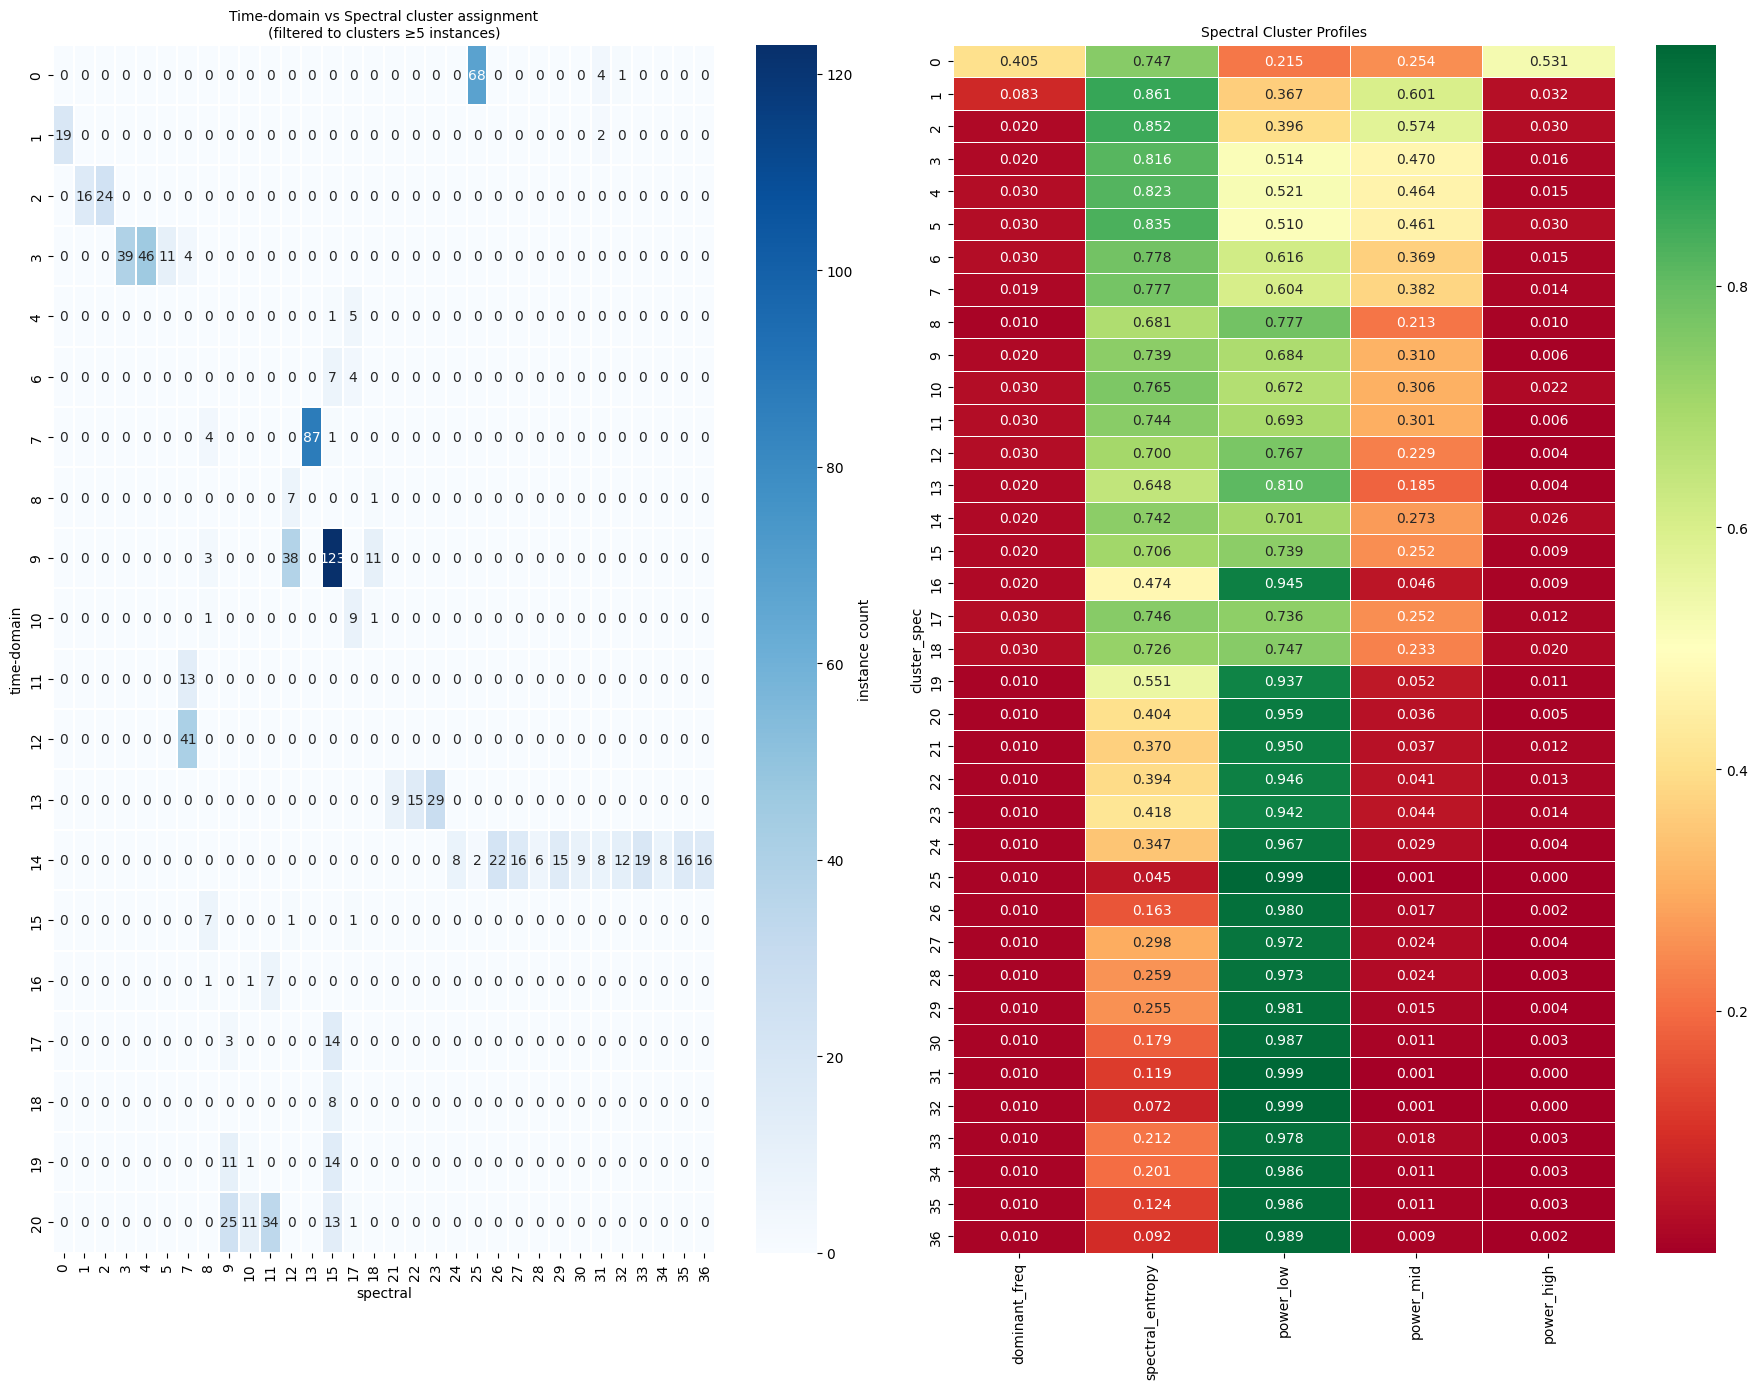

Cross-frame ARI: 0.484


In [20]:
# Confusion-style matrix: time-domain cluster vs spectral cluster
both = df_merged[both_real].copy()
crosstab_cross = pd.crosstab(both['cluster_td'], both['cluster_spec'],
                              rownames=['time-domain'], colnames=['spectral'])
# Filter to rows/cols with at least 5 instances
row_mask = crosstab_cross.sum(axis=1) >= 5
col_mask = crosstab_cross.sum(axis=0) >= 5
crosstab_filt = crosstab_cross.loc[row_mask, col_mask]

fig, axes = plt.subplots(1, 2, figsize=(18, max(6, len(crosstab_filt)*0.6 + 2)))

# Heatmap
sns.heatmap(crosstab_filt, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            linewidths=0.3, cbar_kws={'label': 'instance count'})
axes[0].set_title('Time-domain vs Spectral cluster assignment\n(filtered to clusters ≥5 instances)', fontsize=10)

# Spectral cluster profiles
profiles_spec = df_clean[df_clean['cluster_spec'] != -1].groupby('cluster_spec')[SPECTRAL_COLS].mean().round(4)
sns.heatmap(profiles_spec, annot=True, fmt='.3f', cmap='RdYlGn', center=0.5,
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Spectral Cluster Profiles', fontsize=10)

plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'observer_independence_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Cross-frame ARI: {ari_cross:.3f}')

In [21]:
print('=== Observer-independence verdict ===')
print()
print(f'Cross-frame ARI: {ari_cross:.3f}')
print()

# Checklist
checks = [
    ('COVID1+COVID2 together in spectral space',      c1_spec == c2_spec),
    ('Sunspot separates from COVID in spectral space', sun_spec != c1_spec),
    ('keeling_seasonal isolated',                      ks_spec != c1_spec),
    ('keeling_trend separate from COVID',              kt_spec != c1_spec),
    ('ECG isolated from COVID',                        ecg_spec != c1_spec),
]

passed = sum(1 for _, v in checks if v)
print(f'Key structural tests: {passed}/{len(checks)} passed')
print()
for desc, result in checks:
    print(f'  [{"✓" if result else "✗"}] {desc}')
print()

if ari_cross > 0.3 and passed >= 4:
    print('VERDICT: Observer-independence holds.')
    print('The shape taxonomy reflects structure in the data, not artefacts of the time-domain feature frame.')
elif ari_cross > 0.15 or passed >= 3:
    print('VERDICT: Partial observer-independence — some classes are robust, others are frame-dependent.')
else:
    print('VERDICT: Observer-independence weak — the taxonomy is sensitive to the measurement frame.')

=== Observer-independence verdict ===

Cross-frame ARI: 0.484

Key structural tests: 4/5 passed

  [✗] COVID1+COVID2 together in spectral space
  [✓] Sunspot separates from COVID in spectral space
  [✓] keeling_seasonal isolated
  [✓] keeling_trend separate from COVID
  [✓] ECG isolated from COVID

VERDICT: Observer-independence holds.
The shape taxonomy reflects structure in the data, not artefacts of the time-domain feature frame.


---
## Findings to record

Update this cell manually after running:

- **Cross-frame ARI**: ___
- **Sunspot result**: separates / stays with COVID
- **keeling_seasonal + streamflow**: together or separate in spectral space?
- **Most surprising spectral grouping**: ___
- **Overall observer-independence verdict**: holds / partial / weak
- **What this means for the taxonomy**: ___